# Traditional Criteria Classification (Clean Notebook)

This notebook evaluates handcrafted geometry criteria for complete vs broken object classification.

**Notebook map**
1. Setup and runtime config
2. Dataset discovery
3. Shared helpers and standardized family template
4. Criterion family definitions
5. Dataset pass for all families
6. Manual inference with compact report

## 1. Setup & Imports

In [1]:
import glob
import os
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
from scipy.spatial import ConvexHull

try:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

warnings.filterwarnings('ignore')


def find_project_root(start_dir=None):
    start = Path(start_dir or os.getcwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'Fantastic_Breaks_v1').is_dir():
            return candidate
    raise FileNotFoundError(f'Could not locate project root from {start}')


PROJECT_ROOT = find_project_root()
print(f'Open3D version: {o3d.__version__}')

try:
    _tensor = o3d.core.Tensor([1, 2, 3], device=o3d.core.Device('CUDA:0'))
    USE_CUDA = True
    print(f'Open3D CUDA available on {_tensor.device}')
except Exception as exc:
    USE_CUDA = False
    print(f'Open3D CUDA unavailable ({exc}); falling back to CPU')

OPEN3D_DEVICE = o3d.core.Device('CUDA:0') if USE_CUDA else o3d.core.Device('CPU:0')
print(f'Point feature backend device: {OPEN3D_DEVICE}')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Open3D version: 0.19.0
Open3D CUDA available on CUDA:0
Point feature backend device: CUDA:0


## 2. Runtime Configuration

In [2]:
LABEL_NAMES = np.array(['Complete', 'Broken'])

BASE_CONFIG = {
    'data_root': str(PROJECT_ROOT / 'data' / 'Fantastic_Breaks_v1'),
    'num_points': 8192,
    'point_radius': 0.05,
    'max_nn': 24,
    'max_samples': None,
    'test_ratio': 0.20,
    'split_seed': 42,
    'prediction_threshold': 0.70,
    'verbosity': 'compact',   # compact | detailed
    'progress_every': 10,
    'plot_reference': True,
    'seed': 42,
}

SMOKE_CONFIG = {
    'num_points': 768,
    'max_samples': 24,
    'verbosity': 'compact',
    'progress_every': 5,
    'plot_reference': False,
}


def build_config(run_mode=None, verbosity=None, **overrides):
    resolved_mode = (run_mode or os.environ.get('TRADITIONAL_RUN_MODE', 'full')).strip().lower()
    resolved_verbosity = (verbosity or os.environ.get('TRADITIONAL_VERBOSITY', BASE_CONFIG['verbosity'])).strip().lower()

    if resolved_mode not in {'full', 'smoke'}:
        raise ValueError(f"Unsupported run mode: {resolved_mode}. Expected 'full' or 'smoke'.")
    if resolved_verbosity not in {'compact', 'detailed'}:
        raise ValueError(f"Unsupported verbosity: {resolved_verbosity}. Expected 'compact' or 'detailed'.")

    cfg = deepcopy(BASE_CONFIG)
    if resolved_mode == 'smoke':
        cfg.update(SMOKE_CONFIG)
    cfg.update(overrides)
    cfg['run_mode'] = resolved_mode
    cfg['verbosity'] = resolved_verbosity
    return cfg


def print_config(cfg):
    keys = [
        'run_mode', 'verbosity', 'data_root', 'num_points', 'point_radius',
        'max_nn', 'max_samples', 'test_ratio', 'split_seed',
        'prediction_threshold', 'progress_every', 'plot_reference',
    ]
    print('Traditional criteria configuration')
    for key in keys:
        print(f"  {key:20s}: {cfg[key]}")


CONFIG = build_config()
print_config(CONFIG)

Traditional criteria configuration
  run_mode            : full
  verbosity           : compact
  data_root           : /storage/student6/dev/3D-Segmentation-Restoration/data/Fantastic_Breaks_v1
  num_points          : 8192
  point_radius        : 0.05
  max_nn              : 24
  max_samples         : None
  test_ratio          : 0.2
  split_seed          : 42
  prediction_threshold: 0.7
  progress_every      : 10
  plot_reference      : True


## 3. Data Discovery

In [3]:
def discover_meshes(data_root):
    samples = []
    for category_dir in sorted(glob.glob(os.path.join(data_root, '*'))):
        if not os.path.isdir(category_dir):
            continue
        for object_dir in sorted(glob.glob(os.path.join(category_dir, '*'))):
            if not os.path.isdir(object_dir):
                continue
            object_id = os.path.basename(object_dir)

            complete_path = os.path.join(object_dir, 'model_c.ply')
            broken_path = os.path.join(object_dir, 'model_b_0.ply')

            if os.path.exists(complete_path):
                samples.append({'id': f'{object_id}_c', 'path': complete_path, 'label': 0})
            if os.path.exists(broken_path):
                samples.append({'id': f'{object_id}_b', 'path': broken_path, 'label': 1})
    return samples


def stratified_split_samples(samples, test_ratio=0.2, seed=42):
    labels = np.array([sample['label'] for sample in samples], dtype=np.int32)
    indices = np.arange(len(samples))
    rng = np.random.default_rng(seed)
    rng.shuffle(indices)

    complete_idx = indices[labels[indices] == 0]
    broken_idx = indices[labels[indices] == 1]

    n_test_complete = int(len(complete_idx) * test_ratio)
    n_test_broken = int(len(broken_idx) * test_ratio)

    test_idx = np.concatenate([complete_idx[:n_test_complete], broken_idx[:n_test_broken]])
    train_idx = np.concatenate([complete_idx[n_test_complete:], broken_idx[n_test_broken:]])

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    train_samples = [samples[int(idx)] for idx in train_idx]
    test_samples = [samples[int(idx)] for idx in test_idx]
    return train_samples, test_samples


SAMPLES = discover_meshes(CONFIG['data_root'])
if CONFIG['max_samples'] is not None:
    SAMPLES = SAMPLES[: int(CONFIG['max_samples'])]

TRAIN_SAMPLES, TEST_SAMPLES = stratified_split_samples(
    SAMPLES,
    test_ratio=CONFIG['test_ratio'],
    seed=CONFIG['split_seed'],
)

n_complete = sum(sample['label'] == 0 for sample in SAMPLES)
n_broken = sum(sample['label'] == 1 for sample in SAMPLES)
print(f"Discovered {len(SAMPLES)} meshes: complete={n_complete}, broken={n_broken}")
print(
    f"Split -> train={len(TRAIN_SAMPLES)} "
    f"(complete={sum(s['label']==0 for s in TRAIN_SAMPLES)}, broken={sum(s['label']==1 for s in TRAIN_SAMPLES)}) | "
    f"test={len(TEST_SAMPLES)} "
    f"(complete={sum(s['label']==0 for s in TEST_SAMPLES)}, broken={sum(s['label']==1 for s in TEST_SAMPLES)})"
)

if not SAMPLES:
    raise FileNotFoundError(f"No meshes found under {CONFIG['data_root']}")
if not TRAIN_SAMPLES or not TEST_SAMPLES:
    raise ValueError('Train/test split failed. Increase data size or adjust test_ratio/max_samples.')

Discovered 300 meshes: complete=150, broken=150
Split -> train=240 (complete=120, broken=120) | test=60 (complete=30, broken=30)


## 4. Shared Helpers

In [4]:
def label_name(label_value):
    return LABEL_NAMES[int(label_value)]


def get_valid_inference_object_ids(samples):
    return np.array([sample['id'] for sample in samples], dtype=object)


def print_valid_inference_object_ids(valid_object_ids, limit=None):
    total = len(valid_object_ids)
    if limit is None:
        limit = total
    limit = int(min(limit, total))

    print(f'Valid inference IDs ({total} total):')
    for idx in range(limit):
        print(f"  {idx:3d}: {valid_object_ids[idx]}")
    if limit < total:
        print(f'  ... and {total - limit} more')


def resolve_manual_object_id(valid_object_ids, input_object_index=None, input_object_id=None):
    if input_object_index is None:
        return input_object_id

    object_index = int(input_object_index)
    if object_index < 0 or object_index >= len(valid_object_ids):
        raise IndexError(
            f'input_object_index={object_index} out of range for {len(valid_object_ids)} valid IDs.'
        )

    selected = str(valid_object_ids[object_index])
    if input_object_id is not None and input_object_id != selected:
        print(f'INPUT_OBJECT_INDEX overrides INPUT_OBJECT_ID: {input_object_id} -> {selected}')
    return selected


def load_mesh(mesh_path):
    mesh = o3d.io.read_triangle_mesh(str(mesh_path))
    if mesh.is_empty():
        raise ValueError(f'Empty mesh: {mesh_path}')
    if len(mesh.vertices) == 0 or len(mesh.triangles) == 0:
        raise ValueError(f'Mesh missing vertices or triangles: {mesh_path}')
    mesh.compute_vertex_normals()
    return mesh


def prepare_point_feature_data(mesh, num_points, radius, max_nn):
    vertices = np.asarray(mesh.vertices, dtype=np.float32)

    if num_points is None or len(vertices) <= int(num_points):
        legacy_pcd = o3d.geometry.PointCloud()
        legacy_pcd.points = o3d.utility.Vector3dVector(vertices.astype(np.float64, copy=False))
    else:
        legacy_pcd = mesh.sample_points_uniformly(number_of_points=int(num_points))

    tensor_pcd = o3d.t.geometry.PointCloud.from_legacy(
        legacy_pcd,
        dtype=o3d.core.float32,
        device=OPEN3D_DEVICE,
    )
    tensor_pcd.estimate_normals(max_nn=int(max_nn), radius=float(radius))

    points_t = tensor_pcd.point.positions
    normals_t = tensor_pcd.point.normals

    nns = o3d.core.nns.NearestNeighborSearch(points_t)
    nns.hybrid_index(radius=float(radius))
    nn_idx_t, _, nn_count_t = nns.hybrid_search(points_t, radius=float(radius), max_knn=int(max_nn))

    return {
        'points': points_t.cpu().numpy(),
        'normals': normals_t.cpu().numpy(),
        'nn_idx': nn_idx_t.cpu().numpy(),
        'nn_count': nn_count_t.cpu().numpy(),
    }

In [5]:
def robust_scale(values):
    values = np.asarray(values, dtype=np.float64)
    q25, q75 = np.percentile(values, [25, 75])
    scale = (q75 - q25) / 1.349
    if not np.isfinite(scale) or scale < 1e-6:
        scale = np.std(values)
    if not np.isfinite(scale) or scale < 1e-6:
        scale = np.mean(np.abs(values))
    if not np.isfinite(scale) or scale < 1e-6:
        scale = 1.0
    return float(scale)


def build_family_reference(rows, metric_names, family_name):
    labels = np.array([row['label'] for row in rows], dtype=np.int32)
    values = np.nan_to_num(
        np.array([[row[name] for name in metric_names] for row in rows], dtype=np.float64)
    )

    complete_values = values[labels == 0]
    broken_values = values[labels == 1]
    if len(complete_values) == 0 or len(broken_values) == 0:
        raise ValueError(f'{family_name}: both classes are required to build a reference')

    complete_median = np.median(complete_values, axis=0)
    broken_median = np.median(broken_values, axis=0)
    midpoint = 0.5 * (complete_median + broken_median)

    direction = np.sign(broken_median - complete_median)
    direction[direction == 0] = 1.0

    spread = np.array([robust_scale(values[:, idx]) for idx in range(values.shape[1])], dtype=np.float64)
    spread = np.where(spread > 1e-6, spread, 1.0)

    signed_metric_scores = direction * (values - midpoint) / spread
    family_scores = np.mean(np.tanh(signed_metric_scores), axis=1)
    predictions = (family_scores >= 0.0).astype(np.int32)
    accuracy = float(np.mean(predictions == labels))

    return {
        'family_name': family_name,
        'metric_names': list(metric_names),
        'rows': rows,
        'labels': labels,
        'values': values,
        'complete_median': complete_median,
        'broken_median': broken_median,
        'midpoint': midpoint,
        'direction': direction,
        'spread': spread,
        'family_scores': family_scores,
        'predictions': predictions,
        'accuracy': accuracy,
    }


def score_family_metrics(metrics_dict, reference, prediction_threshold=None):
    metric_values = np.array([metrics_dict[name] for name in reference['metric_names']], dtype=np.float64)
    signed_metric_scores = (
        reference['direction'] * (metric_values - reference['midpoint']) / reference['spread']
    )
    family_score = float(np.mean(np.tanh(signed_metric_scores)))
    broken_prob = float(1.0 / (1.0 + np.exp(-3.0 * family_score)))

    if prediction_threshold is None:
        threshold = None
        prediction = int(broken_prob >= 0.5)
        threshold_margin = None
    else:
        threshold = float(prediction_threshold)
        if threshold < 0.0 or threshold > 1.0:
            raise ValueError('prediction_threshold must be in [0, 1]')
        prediction = int(broken_prob >= threshold)
        threshold_margin = float(broken_prob - threshold)

    return {
        'values': metric_values,
        'signed_metric_scores': signed_metric_scores,
        'score': family_score,
        'pred': prediction,
        'prob': np.array([1.0 - broken_prob, broken_prob], dtype=np.float64),
        'threshold': threshold,
        'threshold_margin': threshold_margin,
    }

### 4.1 Reporting Primitives

In [6]:
def format_table(headers, rows):
    widths = [len(str(header)) for header in headers]
    for row in rows:
        widths = [max(widths[idx], len(str(row[idx]))) for idx in range(len(headers))]

    header_line = ' | '.join(str(headers[idx]).ljust(widths[idx]) for idx in range(len(headers)))
    sep_line = '-+-'.join('-' * widths[idx] for idx in range(len(headers)))
    body_lines = [
        ' | '.join(str(row[idx]).ljust(widths[idx]) for idx in range(len(headers)))
        for row in rows
    ]
    return '\n'.join([header_line, sep_line, *body_lines])


def print_reference_summary(reference):
    headers = ['Metric', 'Complete median', 'Broken median', 'Direction']
    rows = []
    for idx, metric_name in enumerate(reference['metric_names']):
        direction = 'broken > complete' if reference['direction'][idx] > 0 else 'broken < complete'
        rows.append([
            metric_name,
            f"{reference['complete_median'][idx]:.4f}",
            f"{reference['broken_median'][idx]:.4f}",
            direction,
        ])

    print(
        f"\n[{reference['family_name']}] reference accuracy={reference['accuracy']:.4f} "
        f"| samples={len(reference['rows'])}"
    )
    print(format_table(headers, rows))

### 4.2 Family Registration

In [7]:
def plot_family_reference(reference):
    labels = reference['labels']
    scores = reference['family_scores']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.hist(scores[labels == 0], bins=20, alpha=0.7, color='steelblue', label='Complete', density=True)
    ax1.hist(scores[labels == 1], bins=20, alpha=0.7, color='coral', label='Broken', density=True)
    ax1.axvline(0.0, color='black', linestyle='--', linewidth=1)
    ax1.set_title(f"{reference['family_name']} score distribution")
    ax1.set_xlabel('Family score')
    ax1.set_ylabel('Density')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    x = np.arange(len(reference['metric_names']))
    width = 0.35
    ax2.bar(x - width / 2, reference['complete_median'], width, color='steelblue', label='Complete median')
    ax2.bar(x + width / 2, reference['broken_median'], width, color='coral', label='Broken median')
    ax2.set_xticks(x)
    ax2.set_xticklabels(reference['metric_names'], rotation=30, ha='right')
    ax2.set_title(f"{reference['family_name']} medians")
    ax2.grid(True, axis='y', alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()


FAMILY_SPECS = []


def register_family(name, metric_fn, metric_names):
    spec = {
        'name': str(name),
        'metric_fn': metric_fn,
        'metric_names': list(metric_names),
    }
    FAMILY_SPECS.append(spec)
    return spec

### 4.3 Dataset-Pass Runner

In [8]:
def run_family_dataset_pass(samples, family_spec, cfg):
    rows = []
    failed = []
    t0 = time.time()

    for idx, sample in enumerate(samples, start=1):
        should_log = (
            cfg['verbosity'] == 'detailed'
            or idx == 1
            or idx == len(samples)
            or idx % int(cfg['progress_every']) == 0
        )
        if should_log:
            elapsed = time.time() - t0
            eta = elapsed / idx * (len(samples) - idx)
            print(
                f"[{family_spec['name']}] {idx:3d}/{len(samples)} "
                f"elapsed={elapsed:.1f}s eta={eta:.1f}s id={sample['id']}"
            )

        try:
            mesh = load_mesh(sample['path'])
            metrics = family_spec['metric_fn'](mesh)
            rows.append({
                'id': sample['id'],
                'label': sample['label'],
                'path': sample['path'],
                **metrics,
            })
        except Exception as exc:
            failed.append((sample['id'], str(exc)))
            print(f"  WARNING [{family_spec['name']}] {sample['id']}: {exc}")

    if not rows:
        raise RuntimeError(f"{family_spec['name']}: no successful rows")

    reference = build_family_reference(rows, family_spec['metric_names'], family_spec['name'])
    reference['metric_fn'] = family_spec['metric_fn']

    print_reference_summary(reference)
    if cfg['plot_reference']:
        plot_family_reference(reference)

    if failed:
        print(f"{family_spec['name']}: failed on {len(failed)} meshes")

    return reference


def run_all_families(samples, family_specs, cfg):
    references = []
    for family_spec in family_specs:
        reference = run_family_dataset_pass(samples, family_spec, cfg)
        references.append(reference)

    summary_rows = [
        [
            reference['family_name'],
            len(reference['rows']),
            f"{reference['accuracy']:.4f}",
        ]
        for reference in references
    ]
    print('\nFamily summary')
    print(format_table(['Family', 'Samples', 'Reference accuracy'], summary_rows))

    return references

## 5. Criterion Family Template Implementations

In [9]:
def compute_curvature_stats(mesh):
    point_data = prepare_point_feature_data(
        mesh,
        num_points=CONFIG['num_points'],
        radius=CONFIG['point_radius'],
        max_nn=CONFIG['max_nn'],
    )
    points = point_data['points']
    nn_idx = point_data['nn_idx']
    nn_count = point_data['nn_count']

    curvatures = np.zeros(len(points), dtype=np.float64)
    for idx in range(len(points)):
        count = int(nn_count[idx])
        if count < 3:
            continue
        neighbors = points[nn_idx[idx, :count]]
        centered = neighbors - neighbors.mean(axis=0)
        cov = centered.T @ centered / len(neighbors)
        eigenvalues = np.sort(np.abs(np.linalg.eigvalsh(cov)))
        total = eigenvalues.sum()
        if total > 0:
            curvatures[idx] = eigenvalues[0] / total

    return {
        'curv_mean': float(np.mean(curvatures)),
        'curv_std': float(np.std(curvatures)),
        'curv_median': float(np.median(curvatures)),
        'curv_q90': float(np.quantile(curvatures, 0.90)),
        'curv_max': float(np.max(curvatures)),
    }


register_family(
    'Curvature',
    compute_curvature_stats,
    ['curv_mean', 'curv_std', 'curv_median', 'curv_q90', 'curv_max'],
)

{'name': 'Curvature',
 'metric_fn': <function __main__.compute_curvature_stats(mesh)>,
 'metric_names': ['curv_mean',
  'curv_std',
  'curv_median',
  'curv_q90',
  'curv_max']}

In [10]:
def compute_surface_volume_stats(mesh):
    surface_area = mesh.get_surface_area()
    vertices = np.asarray(mesh.vertices)

    try:
        hull = ConvexHull(vertices)
        volume = hull.volume
        hull_area = hull.area
    except Exception:
        volume = 0.0
        hull_area = surface_area

    sa_v_ratio = surface_area / volume if volume > 0 else 0.0
    convexity = surface_area / hull_area if hull_area > 0 else 1.0
    if surface_area > 0 and volume > 0:
        sphericity = (np.pi ** (1 / 3) * (6 * volume) ** (2 / 3)) / surface_area
    else:
        sphericity = 0.0

    return {
        'surface_area': float(surface_area),
        'volume': float(volume),
        'sa_v_ratio': float(sa_v_ratio),
        'convexity': float(convexity),
        'sphericity': float(sphericity),
    }


register_family(
    'Surface / Volume',
    compute_surface_volume_stats,
    ['surface_area', 'volume', 'sa_v_ratio', 'convexity', 'sphericity'],
)

{'name': 'Surface / Volume',
 'metric_fn': <function __main__.compute_surface_volume_stats(mesh)>,
 'metric_names': ['surface_area',
  'volume',
  'sa_v_ratio',
  'convexity',
  'sphericity']}

In [11]:
def compute_normal_stats(mesh):
    point_data = prepare_point_feature_data(
        mesh,
        num_points=CONFIG['num_points'],
        radius=CONFIG['point_radius'],
        max_nn=CONFIG['max_nn'],
    )
    normals = point_data['normals']
    nn_idx = point_data['nn_idx']
    nn_count = point_data['nn_count']

    var_total = float(np.var(normals[:, 0]) + np.var(normals[:, 1]) + np.var(normals[:, 2]))

    consistencies = []
    for idx in range(len(normals)):
        count = int(nn_count[idx])
        if count < 2:
            continue
        neighbors = nn_idx[idx, :count]
        neighbors = neighbors[neighbors != idx]
        if len(neighbors) == 0:
            continue
        dots = np.abs(normals[neighbors] @ normals[idx])
        consistencies.append(np.mean(dots))
    normal_consistency = float(np.mean(consistencies)) if consistencies else 0.0

    theta = np.arccos(np.clip(normals[:, 2], -1, 1))
    phi = np.arctan2(normals[:, 1], normals[:, 0])
    hist, _, _ = np.histogram2d(theta, phi, bins=20)
    hist = hist / hist.sum() if hist.sum() > 0 else hist
    hist = hist[hist > 0]
    normal_entropy = float(-np.sum(hist * np.log2(hist))) if len(hist) > 0 else 0.0

    return {
        'normal_var_total': var_total,
        'normal_entropy': normal_entropy,
        'normal_consistency': normal_consistency,
    }


register_family(
    'Normal statistics',
    compute_normal_stats,
    ['normal_var_total', 'normal_entropy', 'normal_consistency'],
)

{'name': 'Normal statistics',
 'metric_fn': <function __main__.compute_normal_stats(mesh)>,
 'metric_names': ['normal_var_total', 'normal_entropy', 'normal_consistency']}

In [12]:
def compute_shape_descriptors(mesh):
    vertices = np.asarray(mesh.vertices, dtype=np.float64)
    centered = vertices - vertices.mean(axis=0)
    cov = centered.T @ centered / len(vertices)
    eigenvalues = np.sort(np.linalg.eigvalsh(cov))[::-1]
    eigen_sum = eigenvalues.sum()
    ratios = eigenvalues / eigen_sum if eigen_sum > 0 else np.zeros(3, dtype=np.float64)

    elongation = eigenvalues[1] / eigenvalues[0] if eigenvalues[0] > 0 else 0.0
    flatness = eigenvalues[2] / eigenvalues[0] if eigenvalues[0] > 0 else 0.0

    obb = mesh.get_oriented_bounding_box()
    extent = np.sort(obb.extent)[::-1]
    bb_ratio_1 = extent[1] / extent[0] if extent[0] > 0 else 0.0
    bb_ratio_2 = extent[2] / extent[0] if extent[0] > 0 else 0.0
    bb_volume = float(np.prod(extent))

    return {
        'pca_ev_ratio_1': float(ratios[0]),
        'pca_ev_ratio_2': float(ratios[1]),
        'pca_ev_ratio_3': float(ratios[2]),
        'elongation': float(elongation),
        'flatness': float(flatness),
        'bb_aspect_ratio_1': float(bb_ratio_1),
        'bb_aspect_ratio_2': float(bb_ratio_2),
        'bb_volume': float(bb_volume),
    }


register_family(
    'Shape descriptors',
    compute_shape_descriptors,
    [
        'pca_ev_ratio_1',
        'pca_ev_ratio_2',
        'pca_ev_ratio_3',
        'elongation',
        'flatness',
        'bb_aspect_ratio_1',
        'bb_aspect_ratio_2',
        'bb_volume',
    ],
)

{'name': 'Shape descriptors',
 'metric_fn': <function __main__.compute_shape_descriptors(mesh)>,
 'metric_names': ['pca_ev_ratio_1',
  'pca_ev_ratio_2',
  'pca_ev_ratio_3',
  'elongation',
  'flatness',
  'bb_aspect_ratio_1',
  'bb_aspect_ratio_2',
  'bb_volume']}

## 6. Build Family References

[Curvature]   1/240 elapsed=0.0s eta=0.0s id=01031_c
[Curvature]  10/240 elapsed=7.5s eta=173.3s id=01037_b
[Curvature]  20/240 elapsed=15.4s eta=169.3s id=01034_c
[Curvature]  30/240 elapsed=23.3s eta=162.8s id=07004_b
[Curvature]  40/240 elapsed=31.4s eta=157.2s id=00017_c
[Curvature]  50/240 elapsed=39.4s eta=149.9s id=01007_c
[Curvature]  60/240 elapsed=47.3s eta=141.9s id=01044_b
[Curvature]  70/240 elapsed=55.3s eta=134.4s id=09009_b
[Curvature]  80/240 elapsed=63.4s eta=126.8s id=05006_c
[Curvature]  90/240 elapsed=71.1s eta=118.5s id=09034_b
[Curvature] 100/240 elapsed=79.7s eta=111.6s id=05003_c
[Curvature] 110/240 elapsed=87.3s eta=103.2s id=00008_b
[Curvature] 120/240 elapsed=95.1s eta=95.1s id=00011_c
[Curvature] 130/240 elapsed=103.3s eta=87.4s id=00017_b
[Curvature] 140/240 elapsed=111.0s eta=79.3s id=13000_c
[Curvature] 150/240 elapsed=118.6s eta=71.2s id=00039_c
[Curvature] 160/240 elapsed=125.9s eta=63.0s id=00044_c
[Curvature] 170/240 elapsed=134.2s eta=55.3s id=00022

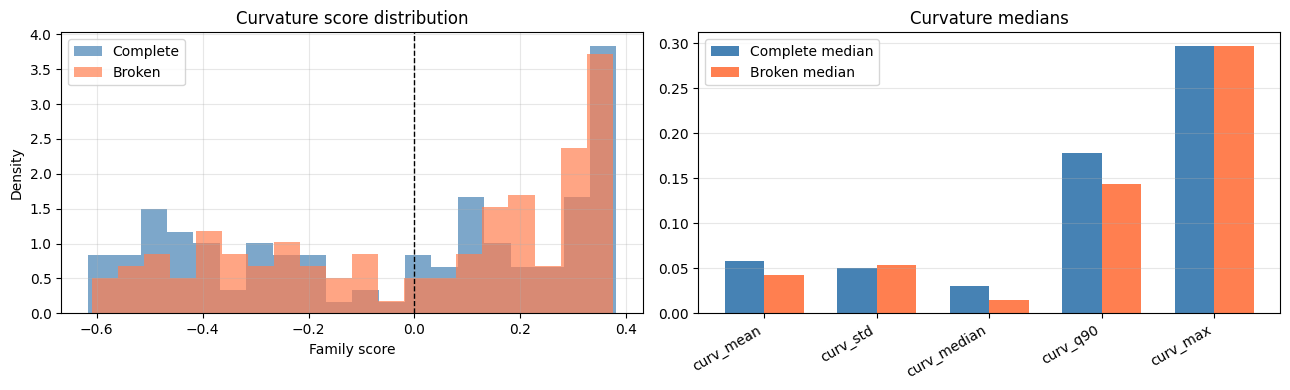

[Surface / Volume]   1/240 elapsed=0.0s eta=0.0s id=01031_c
[Surface / Volume]  10/240 elapsed=11.5s eta=263.9s id=01037_b
[Surface / Volume]  20/240 elapsed=20.6s eta=226.8s id=01034_c
[Surface / Volume]  30/240 elapsed=30.9s eta=216.2s id=07004_b
[Surface / Volume]  40/240 elapsed=41.1s eta=205.7s id=00017_c
[Surface / Volume]  50/240 elapsed=51.6s eta=196.2s id=01007_c
[Surface / Volume]  60/240 elapsed=62.2s eta=186.5s id=01044_b
[Surface / Volume]  70/240 elapsed=72.3s eta=175.5s id=09009_b
[Surface / Volume]  80/240 elapsed=82.1s eta=164.3s id=05006_c
[Surface / Volume]  90/240 elapsed=91.3s eta=152.1s id=09034_b
[Surface / Volume] 100/240 elapsed=102.2s eta=143.1s id=05003_c
[Surface / Volume] 110/240 elapsed=110.8s eta=131.0s id=00008_b
[Surface / Volume] 120/240 elapsed=120.4s eta=120.4s id=00011_c
[Surface / Volume] 130/240 elapsed=131.8s eta=111.5s id=00017_b
[Surface / Volume] 140/240 elapsed=142.2s eta=101.6s id=13000_c
[Surface / Volume] 150/240 elapsed=151.7s eta=91.0s i

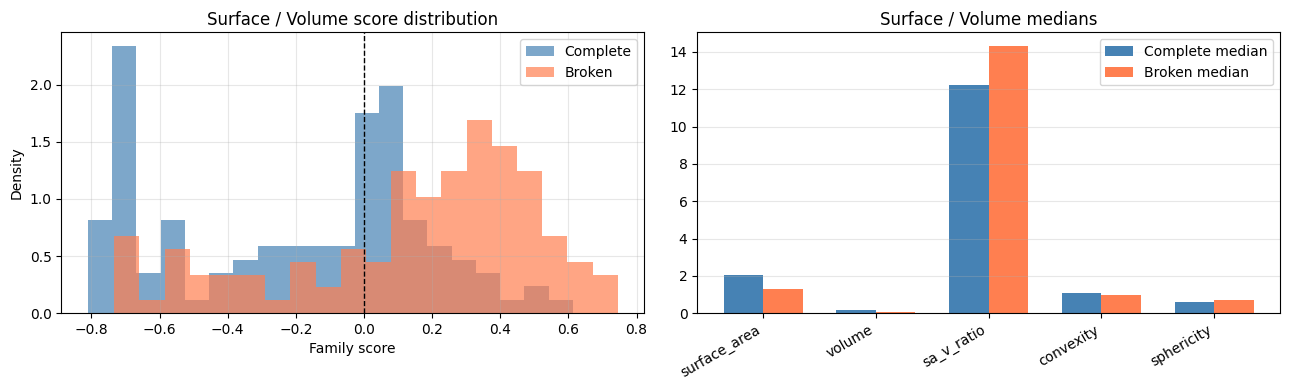

[Normal statistics]   1/240 elapsed=0.0s eta=0.0s id=01031_c
[Normal statistics]  10/240 elapsed=5.9s eta=135.7s id=01037_b
[Normal statistics]  20/240 elapsed=12.1s eta=133.2s id=01034_c
[Normal statistics]  30/240 elapsed=18.3s eta=128.1s id=07004_b
[Normal statistics]  40/240 elapsed=24.5s eta=122.7s id=00017_c
[Normal statistics]  50/240 elapsed=30.6s eta=116.2s id=01007_c
[Normal statistics]  60/240 elapsed=36.6s eta=109.8s id=01044_b
[Normal statistics]  70/240 elapsed=42.8s eta=103.9s id=09009_b
[Normal statistics]  80/240 elapsed=49.0s eta=98.0s id=05006_c
[Normal statistics]  90/240 elapsed=54.8s eta=91.4s id=09034_b
[Normal statistics] 100/240 elapsed=61.6s eta=86.3s id=05003_c
[Normal statistics] 110/240 elapsed=67.6s eta=79.9s id=00008_b
[Normal statistics] 120/240 elapsed=73.6s eta=73.6s id=00011_c
[Normal statistics] 130/240 elapsed=80.2s eta=67.8s id=00017_b
[Normal statistics] 140/240 elapsed=86.3s eta=61.6s id=13000_c
[Normal statistics] 150/240 elapsed=92.0s eta=55.2s

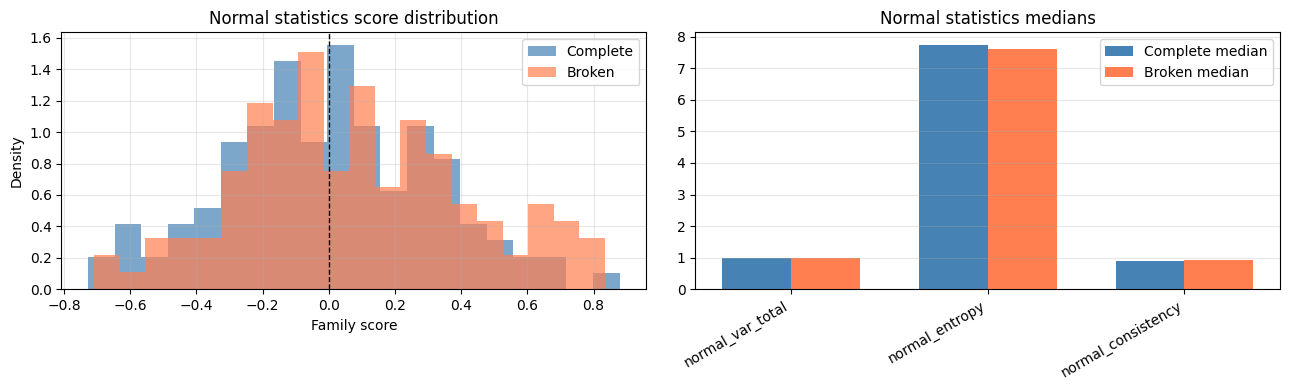

[Shape descriptors]   1/240 elapsed=0.0s eta=0.0s id=01031_c
[Shape descriptors]  10/240 elapsed=10.0s eta=229.8s id=01037_b
[Shape descriptors]  20/240 elapsed=18.4s eta=202.7s id=01034_c
[Shape descriptors]  30/240 elapsed=28.0s eta=195.7s id=07004_b
[Shape descriptors]  40/240 elapsed=37.3s eta=186.4s id=00017_c
[Shape descriptors]  50/240 elapsed=47.0s eta=178.4s id=01007_c
[Shape descriptors]  60/240 elapsed=56.7s eta=170.1s id=01044_b
[Shape descriptors]  70/240 elapsed=66.0s eta=160.3s id=09009_b
[Shape descriptors]  80/240 elapsed=75.1s eta=150.3s id=05006_c
[Shape descriptors]  90/240 elapsed=83.5s eta=139.2s id=09034_b
[Shape descriptors] 100/240 elapsed=93.6s eta=131.0s id=05003_c
[Shape descriptors] 110/240 elapsed=101.1s eta=119.5s id=00008_b
[Shape descriptors] 120/240 elapsed=109.7s eta=109.7s id=00011_c
[Shape descriptors] 130/240 elapsed=119.7s eta=101.3s id=00017_b
[Shape descriptors] 140/240 elapsed=129.0s eta=92.1s id=13000_c
[Shape descriptors] 150/240 elapsed=137.

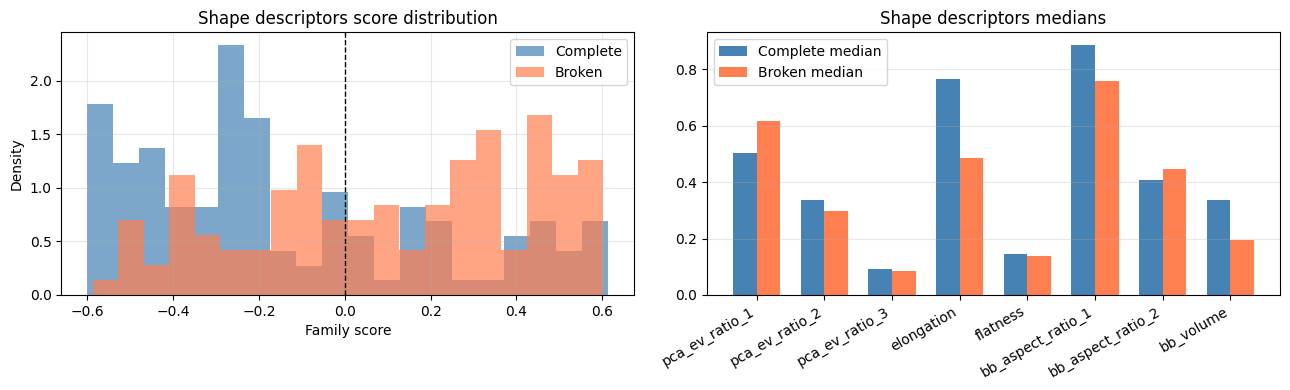


Family summary
Family            | Samples | Reference accuracy
------------------+---------+-------------------
Curvature         | 240     | 0.5125            
Surface / Volume  | 240     | 0.6542            
Normal statistics | 240     | 0.5250            
Shape descriptors | 240     | 0.6542            


In [13]:
FAMILY_REFERENCES = run_all_families(TRAIN_SAMPLES, FAMILY_SPECS, CONFIG)

## 7. Random Test-Set Inference (5 Samples)

### 7.1 Inference Rules + Compact Report

- Random test samples are selected from `TEST_SAMPLES`.
- `prediction_threshold=None` enables threshold-free mode (`argmax` on class probabilities).
- Numeric `prediction_threshold` keeps explicit thresholded decision mode.

In [14]:
def print_compact_inference_report(family_outputs, threshold):
    headers = ['Family', 'BrokenProb', 'Score', 'Decision', 'Rule']
    rows = []
    for output in family_outputs:
        if threshold is None:
            rule = 'argmax'
        else:
            rule = f">= {threshold:.3f}"
        rows.append([
            output['family_name'],
            f"{output['prob'][1]:.3f}",
            f"{output['score']:+.3f}",
            label_name(output['pred']),
            rule,
        ])
    print(format_table(headers, rows))
    if threshold is None:
        print('Decision rule: threshold-free argmax (broken if p_broken >= p_complete).')
    else:
        print(f'Threshold: broken probability >= {threshold:.3f}')

### 7.2 Per-Sample Family Score Plot

In [15]:
def plot_family_scores_for_sample(family_outputs, object_label, overall_pred, ground_truth_label=None):
    family_names = [output['family_name'] for output in family_outputs]
    scores = [output['score'] for output in family_outputs]
    colors = ['coral' if score >= 0 else 'steelblue' for score in scores]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(family_names, scores, color=colors)
    ax.axhline(0.0, color='black', linewidth=1, linestyle='--')

    title = f"Family scores: {object_label} | overall={label_name(overall_pred)}"
    if ground_truth_label is not None:
        title += f" | gt={label_name(ground_truth_label)}"
    ax.set_title(title)
    ax.set_ylabel('Family score')
    ax.grid(True, axis='y', alpha=0.3)

    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

### 7.3 Random Test-Sample Runner

In [16]:
def infer_test_sample(
    family_references,
    sample,
    prediction_threshold=None,
    show_plot=False,
    detailed=False,
):
    object_label = str(sample['id'])
    mesh_path = Path(sample['path']).resolve()
    ground_truth_label = int(sample['label'])
    threshold = None if prediction_threshold is None else float(prediction_threshold)

    mesh = load_mesh(mesh_path)

    family_outputs = []
    for reference in family_references:
        metrics = reference['metric_fn'](mesh)
        scored = score_family_metrics(metrics, reference, prediction_threshold=threshold)
        family_outputs.append({
            'family_name': reference['family_name'],
            'metrics': metrics,
            **scored,
        })

    print(f'Test sample: {object_label}')
    print(f'Mesh path: {mesh_path}')
    print(f'Ground truth: {label_name(ground_truth_label)}')
    print()
    print_compact_inference_report(family_outputs, threshold)

    if detailed:
        print('\nDetailed per-metric signed scores')
        for output, reference in zip(family_outputs, family_references):
            print(f"\n[{output['family_name']}]")
            for metric_name, metric_value, signed_score in zip(
                reference['metric_names'],
                output['values'],
                output['signed_metric_scores'],
            ):
                print(
                    f"  {metric_name:24s} value={metric_value:>10.4f} "
                    f"signed_metric_score={signed_score:+.4f}"
                )

    broken_probs = np.array([output['prob'][1] for output in family_outputs], dtype=np.float64)
    votes = np.array([output['pred'] for output in family_outputs], dtype=np.int32)

    mean_broken_prob = float(np.mean(broken_probs))
    mean_score = float(np.mean([output['score'] for output in family_outputs]))

    if threshold is None:
        overall_pred = int(mean_broken_prob >= 0.5)
        decision_rule = 'argmax'
    else:
        overall_pred = int(mean_broken_prob >= threshold)
        decision_rule = f'>= {threshold:.3f}'

    if votes.sum() * 2 == len(votes):
        vote_reference_pred = int(mean_score >= 0.0)
    else:
        vote_reference_pred = int(votes.sum() > len(votes) / 2.0)

    print()
    print(
        f"Overall: mean broken probability={mean_broken_prob:.3f} | "
        f"rule={decision_rule} -> {label_name(overall_pred)}"
    )
    print(
        f"Family votes: complete={(votes == 0).sum()} | broken={(votes == 1).sum()} | "
        f"vote reference={label_name(vote_reference_pred)}"
    )

    verdict = 'MATCH' if overall_pred == ground_truth_label else 'MISMATCH'
    print(f'Ground-truth comparison: {verdict}')

    if show_plot:
        plot_family_scores_for_sample(
            family_outputs,
            object_label=object_label,
            overall_pred=overall_pred,
            ground_truth_label=ground_truth_label,
        )

    return {
        'object_id': object_label,
        'mesh_path': mesh_path,
        'ground_truth_label': ground_truth_label,
        'prediction_threshold': threshold,
        'overall_pred': overall_pred,
        'overall_broken_probability': mean_broken_prob,
        'vote_reference_pred': vote_reference_pred,
        'family_outputs': family_outputs,
    }


def infer_random_test_samples(
    family_references,
    test_samples,
    num_random=5,
    prediction_threshold=None,
    seed=0,
    show_plots=False,
    detailed=False,
):
    if len(test_samples) == 0:
        raise ValueError('TEST_SAMPLES is empty.')

    sample_count = max(1, min(int(num_random), len(test_samples)))
    rng = np.random.default_rng(seed)
    chosen_idx = np.sort(rng.choice(len(test_samples), size=sample_count, replace=False))

    print(f"Randomly selected test indices: {chosen_idx.tolist()}")
    results = []
    for idx in chosen_idx:
        print(f"\n=== Random test inference {int(idx)} / object {test_samples[int(idx)]['id']} ===")
        result = infer_test_sample(
            family_references,
            test_samples[int(idx)],
            prediction_threshold=prediction_threshold,
            show_plot=show_plots,
            detailed=detailed,
        )
        results.append(result)

    summary_rows = []
    for result in results:
        summary_rows.append([
            result['object_id'],
            label_name(result['ground_truth_label']),
            label_name(result['overall_pred']),
            f"{result['overall_broken_probability']:.3f}",
            'MATCH' if result['ground_truth_label'] == result['overall_pred'] else 'MISMATCH',
        ])

    print('\nRandom test inference summary')
    print(format_table(['Object', 'True', 'Pred', 'p(broken)', 'Match'], summary_rows))
    return results

In [17]:
TEST_OBJECT_IDS = get_valid_inference_object_ids(TEST_SAMPLES)
print_valid_inference_object_ids(TEST_OBJECT_IDS, limit=25)

Valid inference IDs (60 total):
    0: 09006_c
    1: 06002_b
    2: 12006_c
    3: 07005_c
    4: 00043_c
    5: 01000_b
    6: 01020_b
    7: 00002_c
    8: 09018_b
    9: 02010_b
   10: 09017_c
   11: 01024_b
   12: 01021_c
   13: 01008_b
   14: 01047_b
   15: 01002_c
   16: 05014_b
   17: 14001_b
   18: 05007_c
   19: 00028_c
   20: 00020_c
   21: 01012_c
   22: 00040_c
   23: 00037_c
   24: 00015_b
  ... and 35 more


In [18]:
NUM_RANDOM_TEST_SAMPLES = 5
RANDOM_TEST_SEED = CONFIG['seed'] + 2026
PREDICTION_THRESHOLD = None  # None => threshold-free argmax mode
SHOW_RANDOM_TEST_PLOTS = False

RANDOM_TEST_INFERENCE = infer_random_test_samples(
    FAMILY_REFERENCES,
    TEST_SAMPLES,
    num_random=NUM_RANDOM_TEST_SAMPLES,
    prediction_threshold=PREDICTION_THRESHOLD,
    seed=RANDOM_TEST_SEED,
    show_plots=SHOW_RANDOM_TEST_PLOTS,
    detailed=(CONFIG['verbosity'] == 'detailed'),
)

Randomly selected test indices: [6, 29, 38, 45, 52]

=== Random test inference 6 / object 01020_b ===
Test sample: 01020_b
Mesh path: /storage/student6/dev/3D-Segmentation-Restoration/data/Fantastic_Breaks_v1/01/01020/model_b_0.ply
Ground truth: Broken

Family            | BrokenProb | Score  | Decision | Rule  
------------------+------------+--------+----------+-------
Curvature         | 0.727      | +0.326 | Broken   | argmax
Surface / Volume  | 0.802      | +0.466 | Broken   | argmax
Normal statistics | 0.703      | +0.288 | Broken   | argmax
Shape descriptors | 0.440      | -0.081 | Complete | argmax
Decision rule: threshold-free argmax (broken if p_broken >= p_complete).

Overall: mean broken probability=0.668 | rule=argmax -> Broken
Family votes: complete=1 | broken=3 | vote reference=Broken
Ground-truth comparison: MATCH

=== Random test inference 29 / object 02008_c ===
Test sample: 02008_c
Mesh path: /storage/student6/dev/3D-Segmentation-Restoration/data/Fantastic_Breaks_v1/